# Phase 3: Portfolio Testing

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In state 1, Tightening / Carry Squeeze

Reduce: equity beta / credit beta / carry-heavy sleeves
Favor: cash / more defensive positioning

In state 0, Benign / Steady Carry

Run: neutral / baseline exposure

In state 2, Stressed Slowdown / Rebound

Add: equity beta / credit beta / spread-compression trades / reflation / recovery expressions

In [7]:
asset_path = Path('data') / 'asset_returns.parquet'
prob_path = Path('data') / 'prob_oos.parquet'
asset_returns = pd.read_parquet(asset_path)
prob_df = pd.read_parquet(prob_path)

In [2]:
# =========================================================
# 1) Fair ex-ante allocation rule
# =========================================================

STATE_WEIGHTS_FAIR = {
    0: {"SPY": 0.45, "LQD": 0.15, "IEF": 0.30, "cash_ret": 0.10},  # benign / steady carry
    1: {"SPY": 0.15, "LQD": 0.05, "IEF": 0.35, "cash_ret": 0.45},  # tightening / carry squeeze
    2: {"SPY": 0.60, "LQD": 0.20, "IEF": 0.10, "cash_ret": 0.10},  # rebound / rerisk
}

BENCHMARK_6040 = {"SPY": 0.60, "IEF": 0.40, "LQD": 0.00, "cash_ret": 0.00}
BENCHMARK_NEUTRAL = {"SPY": 0.35, "LQD": 0.15, "IEF": 0.35, "cash_ret": 0.15}

In [3]:
# =========================================================
# 2) Helpers
# =========================================================

def _validate_assets(asset_returns, asset_cols):
    missing = [c for c in asset_cols if c not in asset_returns.columns]
    if missing:
        raise ValueError(f"Missing assets in asset_returns: {missing}")


def align_state_and_asset_returns(state_series, asset_returns, asset_cols):
    state_series = state_series.copy()
    asset_returns = asset_returns.copy()

    _validate_assets(asset_returns, asset_cols)

    idx = pd.DatetimeIndex(state_series.index).intersection(pd.DatetimeIndex(asset_returns.index))
    state_series = state_series.loc[idx].sort_index().astype(float)
    asset_returns = asset_returns.loc[idx, asset_cols].sort_index()

    df = pd.concat([state_series.rename("state"), asset_returns], axis=1).dropna()
    state_series = df["state"].astype(int)
    asset_returns = df[asset_cols]

    return state_series, asset_returns


def weight_panel_from_state(state_series, asset_cols, state_weights, lag=1, default_cash_asset="cash_ret"):
    """
    Use lagged state to determine current-period weights.
    """
    sig = state_series.shift(lag)
    w = pd.DataFrame(0.0, index=sig.index, columns=asset_cols)

    for s, wm in state_weights.items():
        mask = sig == s
        for asset, weight in wm.items():
            if asset in w.columns:
                w.loc[mask, asset] = weight

    # Before first usable signal, park in cash if available
    row_sum = w.sum(axis=1)
    if default_cash_asset in w.columns:
        w.loc[row_sum == 0, default_cash_asset] = 1.0

    # Normalize defensively
    row_sum = w.sum(axis=1).replace(0, np.nan)
    w = w.div(row_sum, axis=0).fillna(0.0)

    return w


def static_weight_panel(index, asset_cols, weights):
    w = pd.DataFrame(0.0, index=index, columns=asset_cols)
    for asset, weight in weights.items():
        if asset in w.columns:
            w[asset] = weight
    row_sum = w.sum(axis=1).replace(0, np.nan)
    w = w.div(row_sum, axis=0).fillna(0.0)
    return w


def max_drawdown(ret_series):
    eq = (1.0 + ret_series.fillna(0.0)).cumprod()
    peak = eq.cummax()
    dd = eq / peak - 1.0
    return dd.min()


def perf_stats(ret_series, ann_factor=52):
    r = ret_series.dropna()
    if len(r) == 0:
        return pd.Series(dtype=float)

    ann_ret = (1.0 + r).prod() ** (ann_factor / len(r)) - 1.0
    ann_vol = r.std(ddof=1) * np.sqrt(ann_factor)
    sharpe = np.nan if ann_vol == 0 or pd.isna(ann_vol) else ann_ret / ann_vol

    return pd.Series({
        "n_obs": len(r),
        "cum_return": (1.0 + r).prod() - 1.0,
        "ann_return": ann_ret,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "hit_rate": (r > 0).mean(),
        "max_drawdown": max_drawdown(r),
    })

In [4]:
# =========================================================
# 3) Portfolio backtest
# =========================================================

def backtest_weight_panel(asset_returns, weights, tc_bps=5.0):
    """
    Weekly portfolio backtest.
    tc_bps applies to one-way turnover:
        cost_t = tc * 0.5 * sum_i |w_t - w_{t-1}|
    """
    asset_returns = asset_returns.copy().sort_index()
    weights = weights.copy().reindex(asset_returns.index).fillna(0.0)

    turnover = 0.5 * weights.diff().abs().sum(axis=1).fillna(0.0)
    tc = tc_bps / 1e4

    gross_ret = (weights * asset_returns).sum(axis=1)
    cost = tc * turnover
    net_ret = gross_ret - cost

    out = pd.DataFrame(index=asset_returns.index)
    out["gross_ret"] = gross_ret
    out["turnover"] = turnover
    out["cost"] = cost
    out["net_ret"] = net_ret
    return out


def backtest_dynamic_state_strategy(
    state_series,
    asset_returns,
    state_weights,
    asset_cols=("SPY", "LQD", "IEF", "cash_ret"),
    lag=1,
    tc_bps=5.0,
):
    state_series, asset_returns = align_state_and_asset_returns(state_series, asset_returns, list(asset_cols))

    w = weight_panel_from_state(
        state_series=state_series,
        asset_cols=list(asset_cols),
        state_weights=state_weights,
        lag=lag,
        default_cash_asset="cash_ret",
    )

    bt = backtest_weight_panel(asset_returns, w, tc_bps=tc_bps)
    bt["state"] = state_series
    return bt, w, asset_returns


def backtest_static_strategy(
    asset_returns,
    weights_dict,
    asset_cols=("SPY", "LQD", "IEF", "cash_ret"),
    tc_bps=0.0,
):
    asset_returns = asset_returns.copy()
    _validate_assets(asset_returns, list(asset_cols))
    asset_returns = asset_returns[list(asset_cols)].dropna().copy()

    w = static_weight_panel(asset_returns.index, list(asset_cols), weights_dict)
    bt = backtest_weight_panel(asset_returns, w, tc_bps=tc_bps)
    return bt, w

In [5]:
# =========================================================
# 4) Out-of-time evaluation
# =========================================================

def evaluate_subperiods(return_dict, test_starts, ann_factor=52):
    """
    return_dict: {strategy_name: pd.Series of returns}
    test_starts: iterable of dates
    """
    rows = []

    for name, ret in return_dict.items():
        for start in test_starts:
            start = pd.Timestamp(start)
            sub = ret.loc[ret.index >= start]

            stats = perf_stats(sub, ann_factor=ann_factor)
            stats["strategy"] = name
            stats["test_start"] = start
            rows.append(stats)

    out = pd.DataFrame(rows)
    cols = ["strategy", "test_start", "n_obs", "cum_return", "ann_return", "ann_vol", "sharpe", "hit_rate", "max_drawdown"]
    return out[cols].sort_values(["test_start", "strategy"]).reset_index(drop=True)

In [8]:
# =========================================================
# 5) Plot helper
# =========================================================

def plot_equity_curves(return_dict, start=None, title="Equity Curves"):
    fig, ax = plt.subplots(figsize=(12, 6))

    for name, ret in return_dict.items():
        s = ret.copy()
        if start is not None:
            s = s.loc[s.index >= pd.Timestamp(start)]
        eq = (1.0 + s.fillna(0.0)).cumprod()
        ax.plot(eq.index, eq.values, label=name)

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

,n_obs,cum_return,ann_return,ann_vol,sharpe,hit_rate,max_drawdown
Dynamic_regime,463.0,0.754061,0.065145,0.078349,0.831476,0.570194,-0.162080
Benchmark_60_40,463.0,0.921539,0.076111,0.108984,0.698365,0.570194,-0.216901
Benchmark_neutral,463.0,0.501326,0.046695,0.076997,0.606448,0.565875,-0.184320


,strategy,test_start,n_obs,cum_return,ann_return,ann_vol,sharpe,hit_rate,max_drawdown
0,Benchmark_60_40,2024-01-05,113.0,0.262259,0.113131,0.089049,1.270430,0.557522,-0.098347
1,Benchmark_neutral,2024-01-05,113.0,0.166998,0.073654,0.060314,1.221169,0.566372,-0.057131
2,Dynamic_regime,2024-01-05,113.0,0.191834,0.084108,0.081659,1.029996,0.548673,-0.100022
3,Benchmark_60_40,2025-01-03,61.0,0.121222,0.102453,0.092137,1.111967,0.524590,-0.092715
4,Benchmark_neutral,2025-01-03,61.0,0.092097,0.077993,0.056968,1.369079,0.590164,-0.050056
5,Dynamic_regime,2025-01-03,61.0,0.101330,0.085758,0.086393,0.992644,0.524590,-0.090820


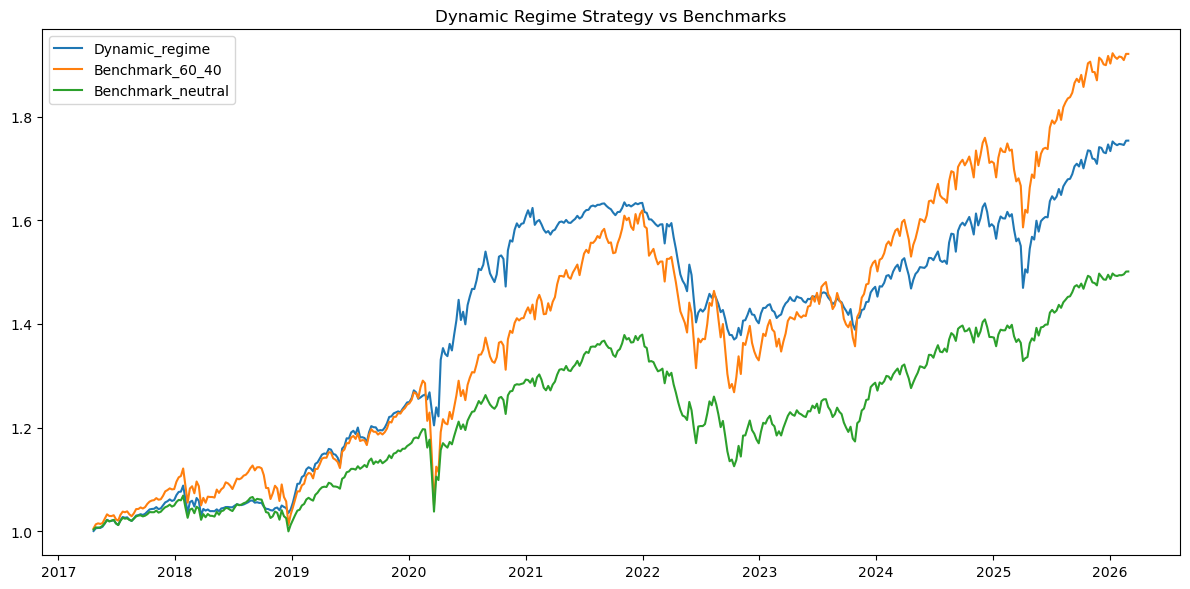

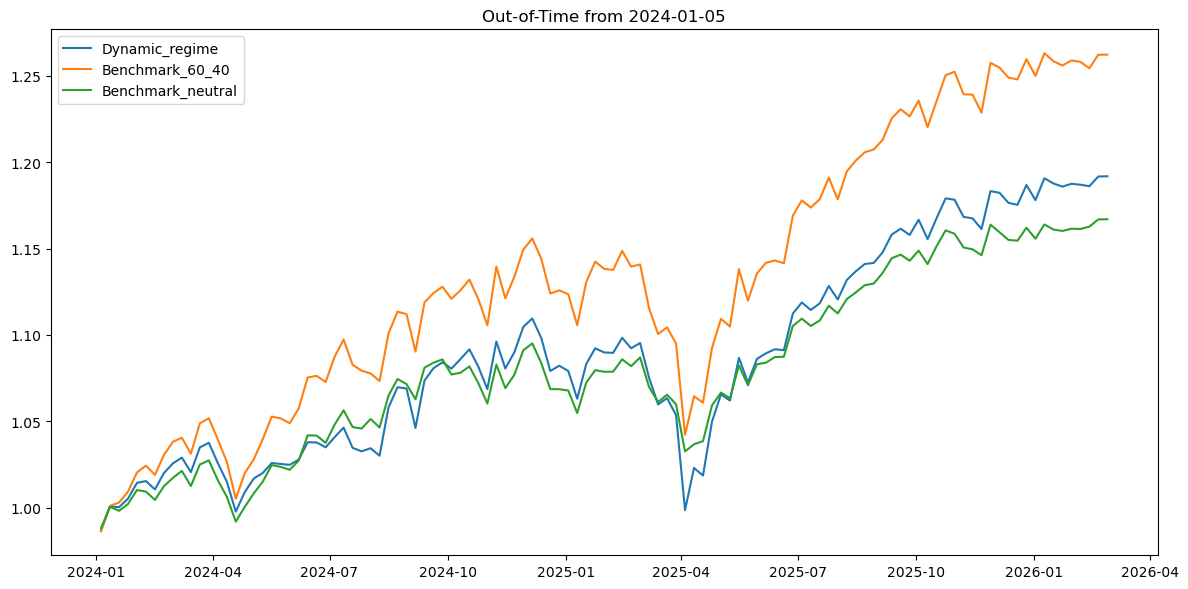

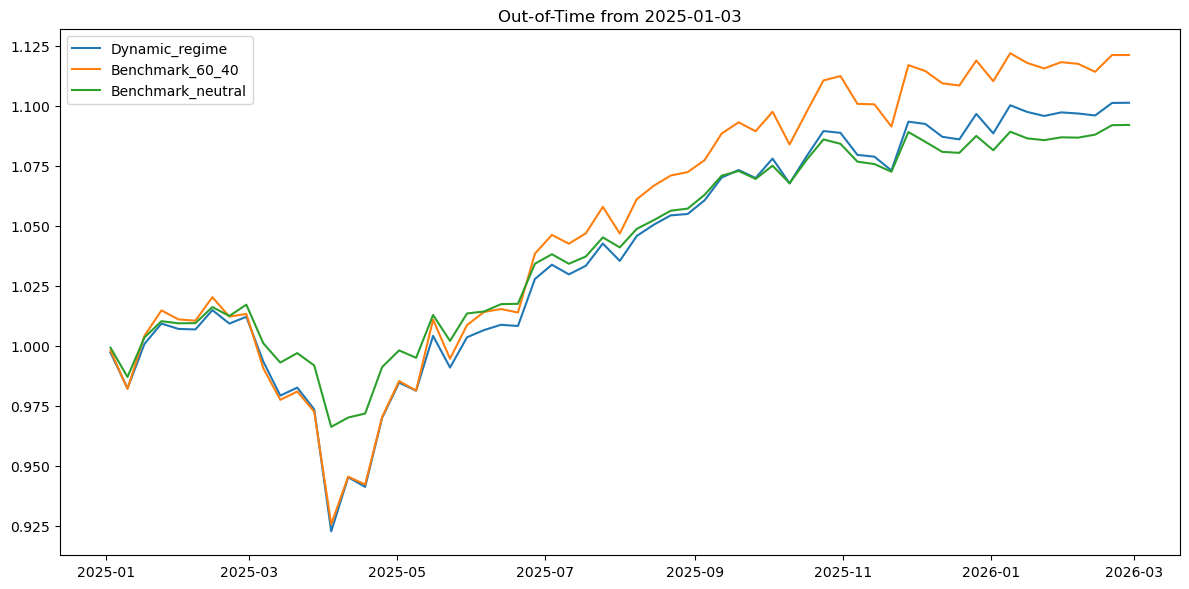

In [9]:
# Use the enriched 3-state pseudo-OOS smoothed states
state_series = prob_df["state"]

# Assets used in the allocation rule
asset_cols = ["SPY", "LQD", "IEF", "cash_ret"]

# Align and backtest dynamic strategy
bt_dyn, w_dyn, asset_ret_used = backtest_dynamic_state_strategy(
    state_series=state_series,
    asset_returns=asset_returns,
    state_weights=STATE_WEIGHTS_FAIR,
    asset_cols=asset_cols,
    lag=1,          # crucial: no lookahead
    tc_bps=5.0,     # fair but light transaction cost
)

# Static benchmarks on the same aligned sample
bt_6040, w_6040 = backtest_static_strategy(
    asset_returns=asset_ret_used,
    weights_dict=BENCHMARK_6040,
    asset_cols=asset_cols,
    tc_bps=0.0,
)

bt_neutral, w_neutral = backtest_static_strategy(
    asset_returns=asset_ret_used,
    weights_dict=BENCHMARK_NEUTRAL,
    asset_cols=asset_cols,
    tc_bps=0.0,
)

# Collect return series
ret_dict = {
    "Dynamic_regime": bt_dyn["net_ret"],
    "Benchmark_60_40": bt_6040["net_ret"],
    "Benchmark_neutral": bt_neutral["net_ret"],
}

# Full-sample stats on the aligned pseudo-OOS period
full_stats = pd.concat(
    {name: perf_stats(ret) for name, ret in ret_dict.items()},
    axis=1
).T
display(full_stats)

# Out-of-time windows
oot_stats = evaluate_subperiods(
    return_dict=ret_dict,
    test_starts=[
        "2024-01-05",
        "2025-01-03",
    ],
)
display(oot_stats)

# Plots
plot_equity_curves(ret_dict, title="Dynamic Regime Strategy vs Benchmarks")
plot_equity_curves(ret_dict, start="2024-01-05", title="Out-of-Time from 2024-01-05")
plot_equity_curves(ret_dict, start="2025-01-03", title="Out-of-Time from 2025-01-03")